# Analisis Sentimen Judi Online (Judol)

Klasifikasi sentimen komentar pengguna X terhadap judi online menggunakan XGBoost dengan pembanding Logistic Regression, Naive Bayes, Decision Tree, Random Forest, dan SVM.

Dataset: 1.508 data berlabel hasil majority vote 3 anotator. Kelas: positif, netral, negatif. Fitur: TF-IDF unigram, bigram, dan trigram.

## 1. Instalasi & Import Library

In [1]:
!pip install xgboost wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from sklearn.base import clone
from xgboost import XGBClassifier

MODEL_PALETTE = ['#2196F3','#9C27B0','#FF9800','#4CAF50','#F44336','#FF6F00']



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load & Gabung Data Anotator (Majority Vote)

In [2]:
import pandas as pd
from collections import Counter

a1 = pd.read_csv('../data/anotator_1.csv')
a2 = pd.read_csv('../data/anotator_2.csv')
a3 = pd.read_csv('../data/anotator_3.csv')

def majority_vote(row):
    return Counter(row).most_common(1)[0][0]

labels_df = pd.DataFrame({'a1': a1['label_anotator'],
                           'a2': a2['label_anotator'],
                           'a3': a3['label_anotator']})
majority = labels_df.apply(majority_vote, axis=1)

df = pd.DataFrame({'text': a1['TEXT_SIAP'], 'label': majority}).dropna().reset_index(drop=True)
df['text']     = df['text'].astype(str)
df['text_len'] = df['text'].str.split().str.len()

print(f"Total data : {df.shape[0]} baris")
print("\nDistribusi label (majority vote):")
print(df['label'].value_counts())
df.head(3)

Total data : 1508 baris

Distribusi label (majority vote):
label
negatif    643
netral     637
positif    228
Name: count, dtype: int64


,text,label,text_len
0,tidak benar judi online judi offline sama sama...,negatif,27
1,sini haram daging babi pencuri malak tipu judi...,negatif,10
2,lihat kemarin tertawa asli lagian main judi ta...,negatif,12


## 2.5 Analisis Kualitas Dataset

,Jumlah,Persentase (%)
label,,
negatif,643,42.64
netral,637,42.24
positif,228,15.12


Imbalance ratio: 2.82
Panjang token - min: 2 max: 45 mean: 16.1 median: 14 std: 9.3


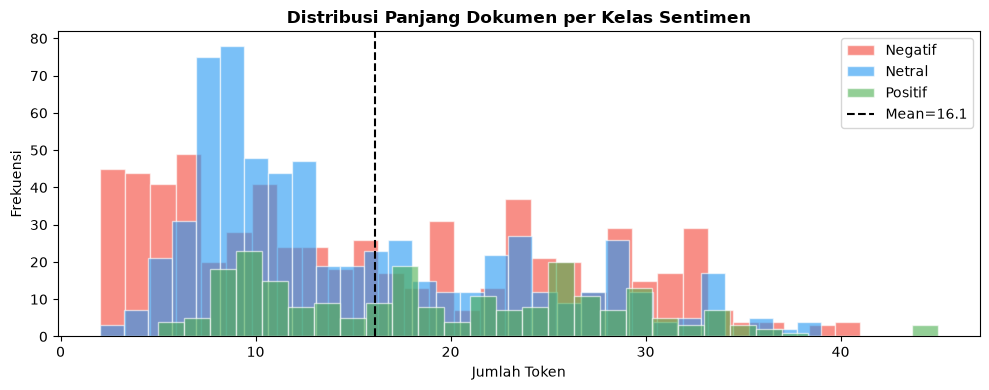

Total token: 24283
Token unik: 3983
Type-token ratio: 0.164
Dokumen <=2 token: 14
Dokumen >=50 token: 0


,text,label,text_len
4,harap judi,negatif,2
70,bacot judi,negatif,2
87,bacot judi,negatif,2
124,anda judi,negatif,2
138,anda judi,negatif,2


In [3]:
counts = df['label'].value_counts()
total = len(df)
pct = (counts / total * 100).round(2)
imbalance_ratio = counts.max() / counts.min()

dist_df = pd.DataFrame({'Jumlah': counts, 'Persentase (%)': pct})
display(dist_df)
print('Imbalance ratio:', round(imbalance_ratio, 2))

stats = df['text_len'].describe().round(2)
print('Panjang token - min:', int(stats['min']), 'max:', int(stats['max']),
      'mean:', round(stats['mean'], 1), 'median:', int(stats['50%']), 'std:', round(stats['std'], 1))

fig, ax = plt.subplots(figsize=(10, 4))
for label, color in zip(['negatif','netral','positif'], ['#F44336','#2196F3','#4CAF50']):
    ax.hist(df[df['label']==label]['text_len'], bins=30, alpha=0.6,
            label=label.capitalize(), color=color, edgecolor='white')
ax.axvline(df['text_len'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f"Mean={df['text_len'].mean():.1f}")
ax.set_title('Distribusi Panjang Dokumen per Kelas Sentimen', fontweight='bold')
ax.set_xlabel('Jumlah Token'); ax.set_ylabel('Frekuensi'); ax.legend()
plt.tight_layout(); plt.show()

all_words = ' '.join(df['text']).split()
vocab = set(all_words)
print('Total token:', len(all_words))
print('Token unik:', len(vocab))
print('Type-token ratio:', round(len(vocab)/len(all_words), 4))

short = df[df['text_len'] <= 2]
long_ = df[df['text_len'] >= 50]
print('Dokumen <=2 token:', len(short))
print('Dokumen >=50 token:', len(long_))
if len(short) > 0:
    display(short[['text','label','text_len']].head(5))

## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Kelas & Panjang Teks

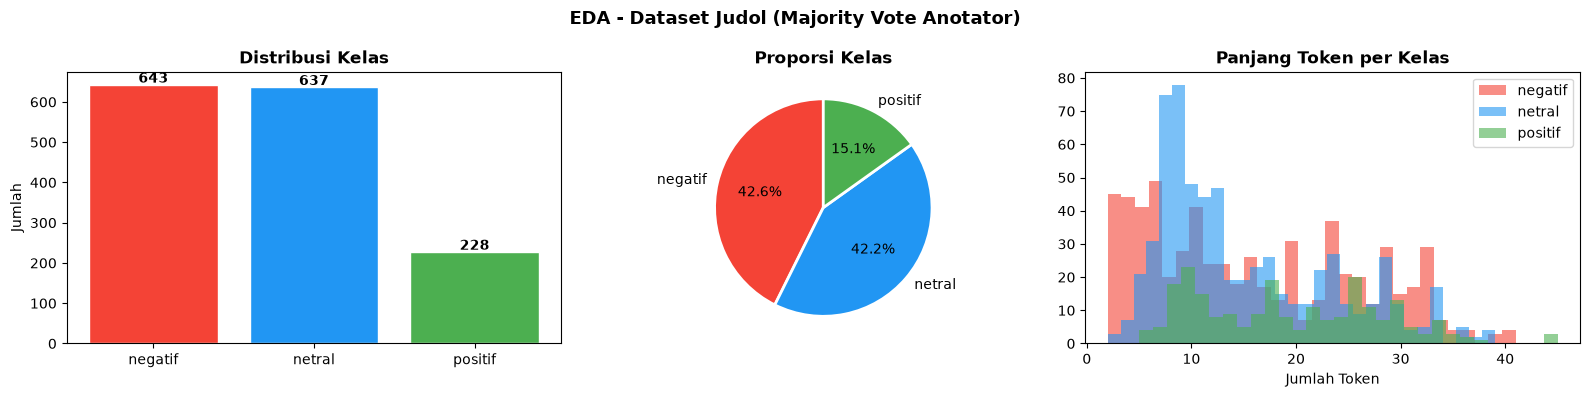


Rata-rata panjang token per kelas:
label
negatif    16.0
netral     15.1
positif    19.3
Name: text_len, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('EDA - Dataset Judol (Majority Vote Anotator)', fontsize=13, fontweight='bold')

counts = df['label'].value_counts()
colors = ['#F44336','#2196F3','#4CAF50']

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+5, str(val), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Kelas', fontweight='bold'); axes[0].set_ylabel('Jumlah')

axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporsi Kelas', fontweight='bold')

for label, color in zip(['negatif','netral','positif'], colors):
    axes[2].hist(df[df['label']==label]['text_len'], bins=30,
                 alpha=0.6, label=label, color=color)
axes[2].set_title('Panjang Token per Kelas', fontweight='bold')
axes[2].set_xlabel('Jumlah Token'); axes[2].legend()

plt.tight_layout(); plt.show()
print("\nRata-rata panjang token per kelas:")
print(df.groupby('label')['text_len'].mean().round(1))


### 3.2 WordCloud per Kelas

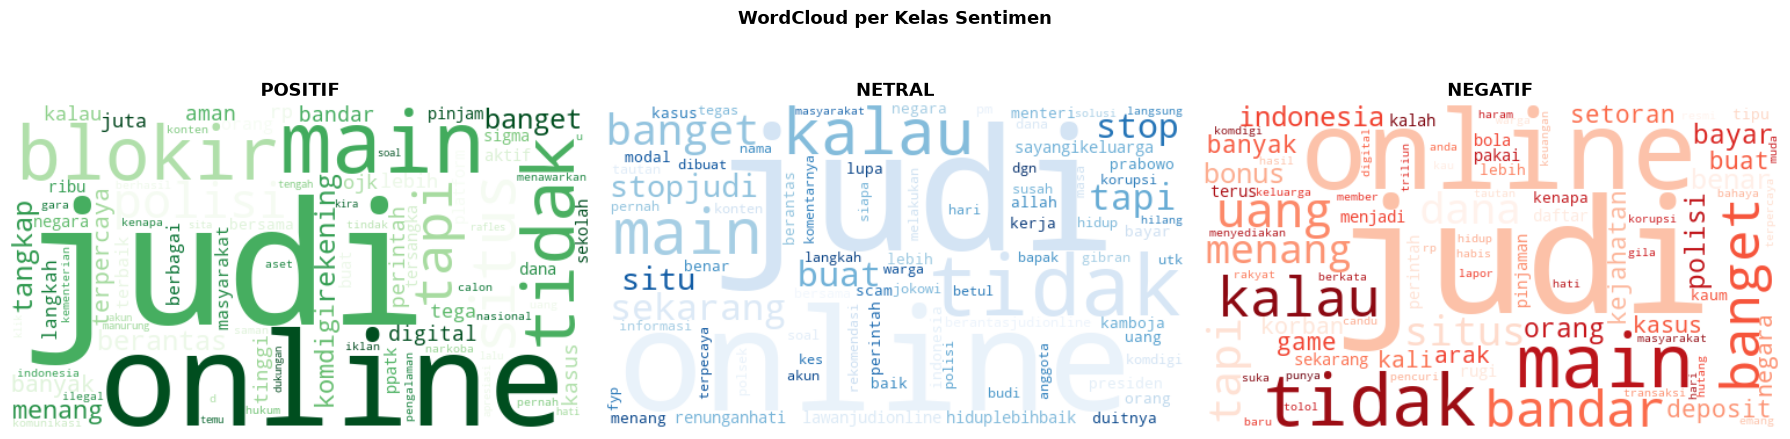

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('WordCloud per Kelas Sentimen', fontsize=13, fontweight='bold')

for ax, (label, cmap) in zip(axes, [('positif','Greens'),('netral','Blues'),('negatif','Reds')]):
    text = ' '.join(df[df['label']==label]['text'])
    wc = WordCloud(width=500, height=280, background_color='white', colormap=cmap,
                   max_words=80, collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(f'{label.upper()}', fontweight='bold', fontsize=13)

plt.tight_layout(); plt.show()


### 3.3 Top 20 Kata per Kelas (Unigram, Bigram, Trigram)

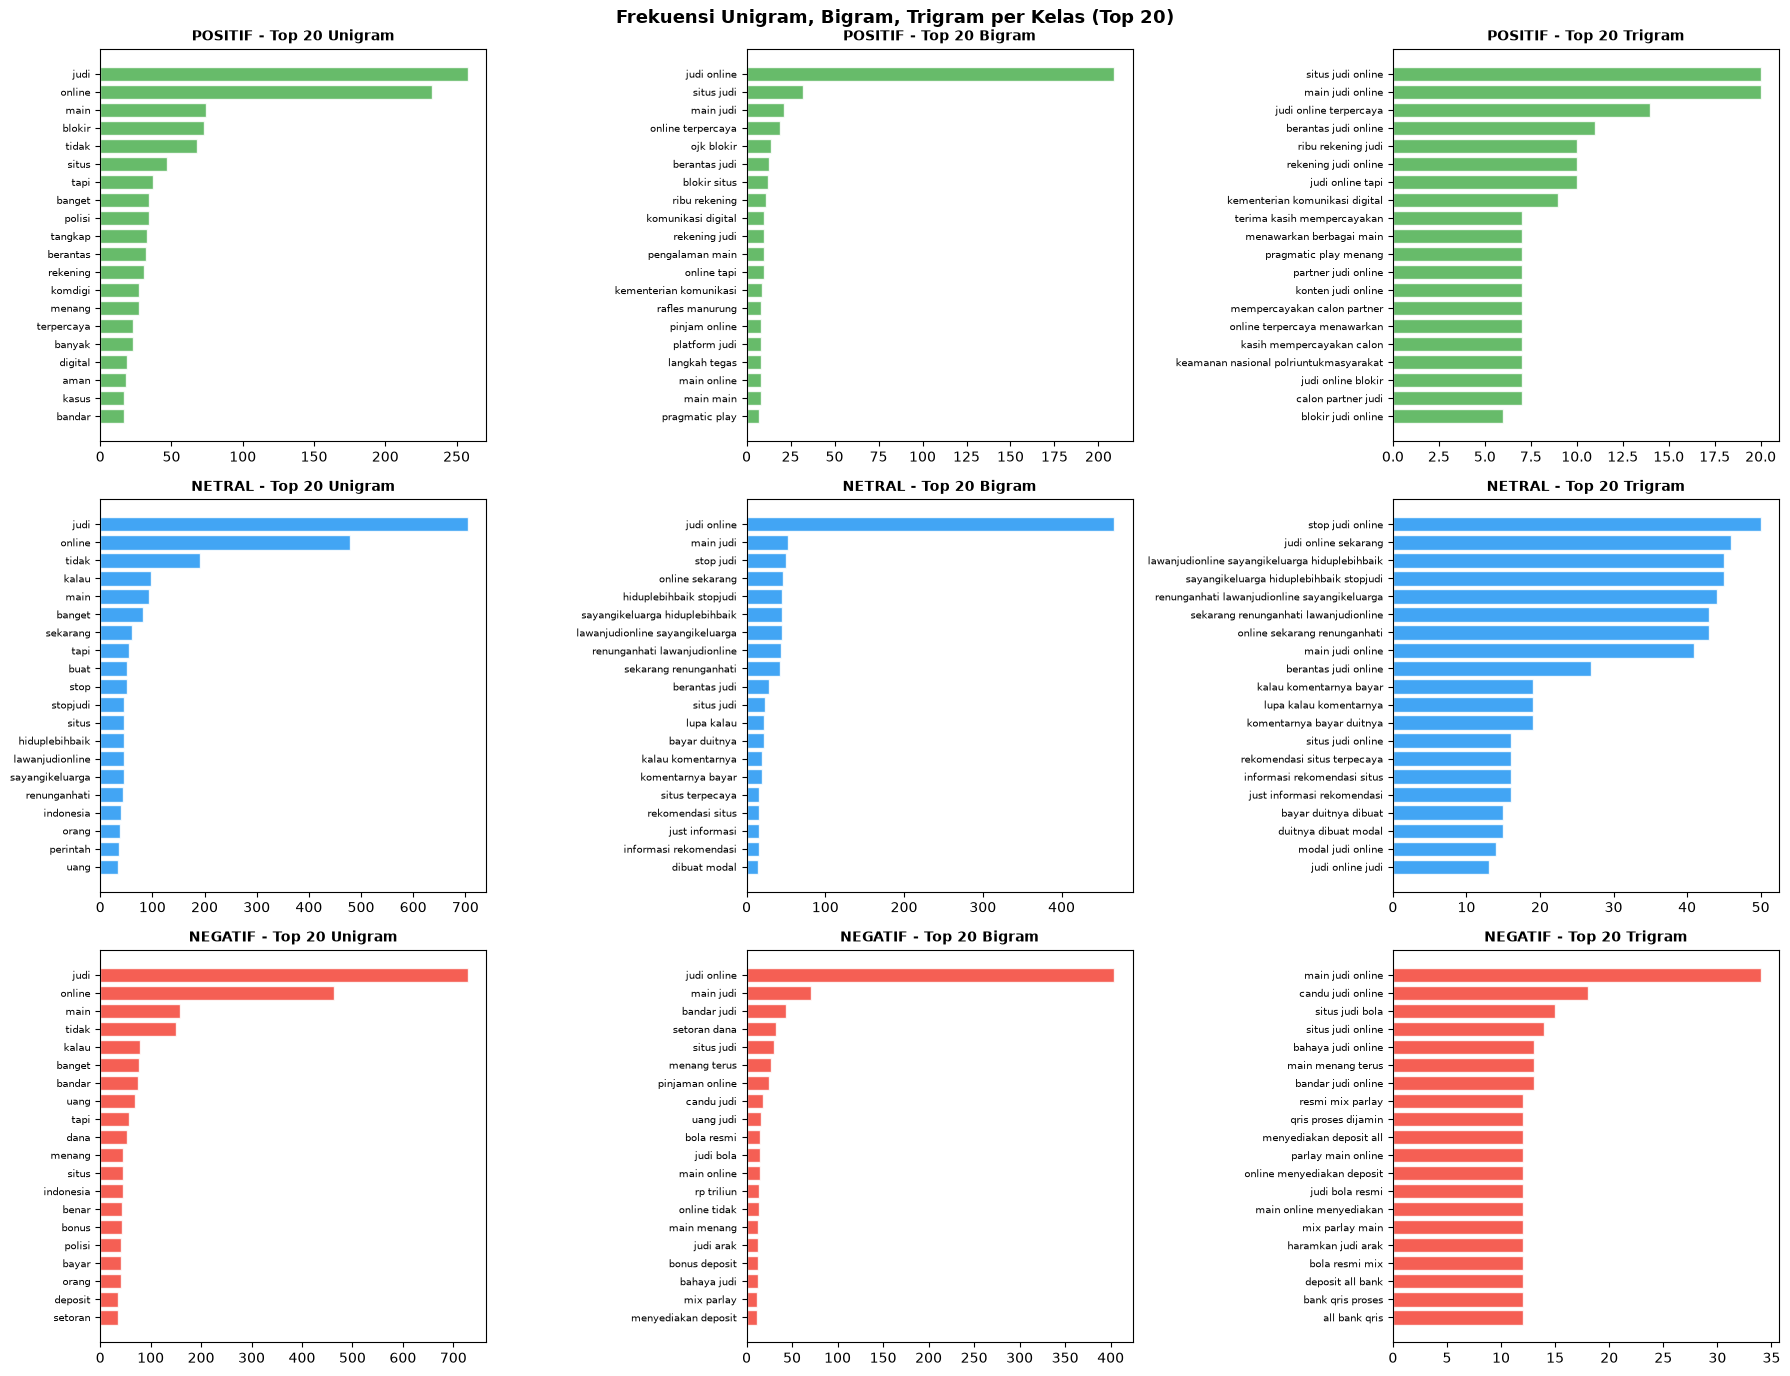

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Frekuensi Unigram, Bigram, Trigram per Kelas (Top 20)', fontsize=13, fontweight='bold')

label_colors = [('positif','#4CAF50'),('netral','#2196F3'),('negatif','#F44336')]
ngram_cfg = [(1,'Unigram'),(2,'Bigram'),(3,'Trigram')]

for row_idx, (label, color) in enumerate(label_colors):
    texts = df[df['label']==label]['text'].tolist()
    for col_idx, (ng, ng_label) in enumerate(ngram_cfg):
        vec = CountVectorizer(max_features=20, ngram_range=(ng,ng))
        X_v = vec.fit_transform(texts)
        freq = pd.Series(X_v.toarray().sum(axis=0), index=vec.get_feature_names_out()).sort_values()
        axes[row_idx][col_idx].barh(freq.index, freq.values, color=color, edgecolor='white', alpha=0.85)
        axes[row_idx][col_idx].set_title(f'{label.upper()} - Top 20 {ng_label}', fontweight='bold', fontsize=10)
        axes[row_idx][col_idx].tick_params(axis='y', labelsize=7)

plt.tight_layout(); plt.show()

### 3.3b Word Frequency Distribution

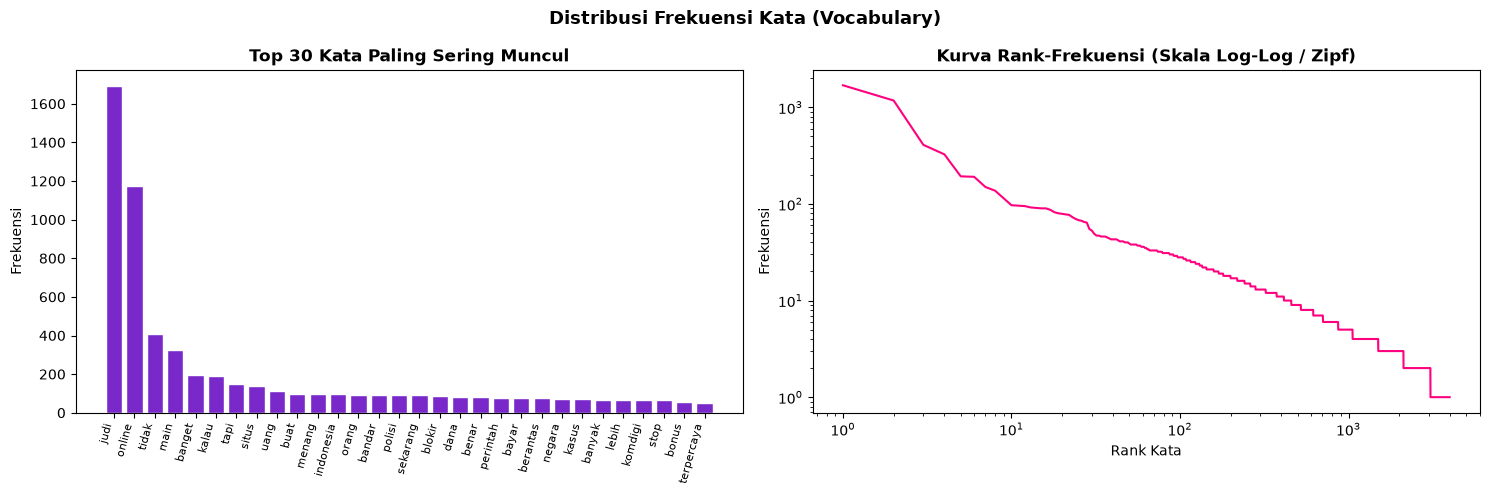

Total token: 24283 | Vocabulary unik: 3983


In [7]:
all_tokens = ' '.join(df['text']).split()
freq_all = pd.Series(Counter(all_tokens)).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Distribusi Frekuensi Kata (Vocabulary)', fontsize=13, fontweight='bold')

top30 = freq_all.head(30)
axes[0].bar(range(len(top30)), top30.values, color='#7928CA', edgecolor='white')
axes[0].set_xticks(range(len(top30)))
axes[0].set_xticklabels(top30.index, rotation=75, ha='right', fontsize=8)
axes[0].set_title('Top 30 Kata Paling Sering Muncul', fontweight='bold')
axes[0].set_ylabel('Frekuensi')

ranks = np.arange(1, len(freq_all)+1)
axes[1].loglog(ranks, freq_all.values, color='#FF007F')
axes[1].set_title('Kurva Rank-Frekuensi (Skala Log-Log / Zipf)', fontweight='bold')
axes[1].set_xlabel('Rank Kata'); axes[1].set_ylabel('Frekuensi')

plt.tight_layout(); plt.show()
print('Total token:', len(all_tokens), '| Vocabulary unik:', len(freq_all))

### 3.4 Tabel Kuantitatif Preprocessing

In [8]:
df_clean = pd.read_csv('../data/cleaned_data judol.csv')
df_norm = pd.read_csv('../data/normalisasi_datajudol.csv')
df_stop = pd.read_csv('../data/stopword_datajudol.csv')
df_stem = pd.read_csv('../data/stemming_datajudol.csv')

def avg_tok(s): return s.dropna().astype(str).apply(lambda x: len(x.split())).mean()
def tot_tok(s): return s.dropna().astype(str).apply(lambda x: len(x.split())).sum()

raw_avg = avg_tok(df_clean['full_text'])
raw_tot = tot_tok(df_clean['full_text'])

rows = [
    ('Raw Text (sebelum cleaning)', raw_avg, raw_tot),
    ('Cleaning (hapus noise/URL)', avg_tok(df_clean['full_text']), tot_tok(df_clean['full_text'])),
    ('Normalisasi (kamus singkatan)', avg_tok(df_norm['corrected_text']), tot_tok(df_norm['corrected_text'])),
    ('Stopword Removal', avg_tok(df_stop['stop_word']), tot_tok(df_stop['stop_word'])),
    ('Stemming (TEXT SIAP)', avg_tok(df_stem['stemming']), tot_tok(df_stem['stemming'])),
]
tbl_pre = pd.DataFrame(rows, columns=['Tahapan','Rata-rata Token/Dok','Total Token'])
tbl_pre['Reduksi (%)'] = ((1 - tbl_pre['Total Token'] / raw_tot) * 100).round(1)
tbl_pre['Rata-rata Token/Dok'] = tbl_pre['Rata-rata Token/Dok'].round(1)
display(tbl_pre)
print('Total reduksi:', f'{raw_tot:,}', '->', f"{int(tbl_pre['Total Token'].iloc[-1]):,}", 'token')

,Tahapan,Rata-rata Token/Dok,Total Token,Reduksi (%)
0,Raw Text (sebelum cleaning),11.4,13671,0.0
1,Cleaning (hapus noise/URL),11.4,13671,0.0
2,Normalisasi (kamus singkatan),11.7,14098,-3.1
3,Stopword Removal,12.5,14991,-9.7
4,Stemming (TEXT SIAP),10.4,12423,9.1


Total reduksi: 13,671 -> 12,423 token


### 3.5 Distribusi Sentimen - Jumlah & Persentase

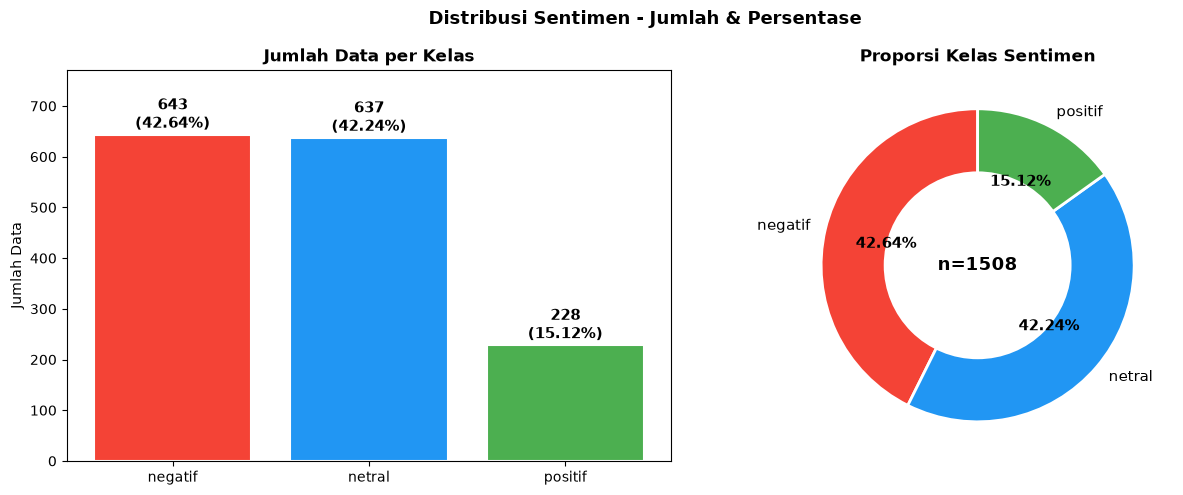

,Kelas,Jumlah,Persentase (%)
0,negatif,643,42.64
1,netral,637,42.24
2,positif,228,15.12


Imbalance ratio: 2.82


In [9]:
counts = df['label'].value_counts()
pct = (counts / len(df) * 100).round(2)
colors = ['#F44336','#2196F3','#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Sentimen - Jumlah & Persentase', fontsize=13, fontweight='bold')

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val, p in zip(bars, counts.values, pct.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+4, f'{val}\n({p}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Jumlah Data per Kelas', fontweight='bold')
axes[0].set_ylabel('Jumlah Data')
axes[0].set_ylim(0, counts.max()*1.2)

wedges, _, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=colors,
    autopct='%1.2f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':11})
for at in autotexts:
    at.set_fontweight('bold')
axes[1].add_patch(plt.Circle((0,0), 0.60, fc='white'))
axes[1].set_title('Proporsi Kelas Sentimen', fontweight='bold')
axes[1].text(0, 0, f'n={len(df)}', ha='center', va='center', fontsize=13, fontweight='bold')

plt.tight_layout(); plt.show()

summary = pd.DataFrame({'Kelas': counts.index, 'Jumlah': counts.values,
                        'Persentase (%)': pct.values}).reset_index(drop=True)
display(summary)
print('Imbalance ratio:', round(counts.max()/counts.min(), 2))

### 3.6 Visualisasi Bobot TF-IDF Rata-Rata (Bukan Frekuensi Mentah)

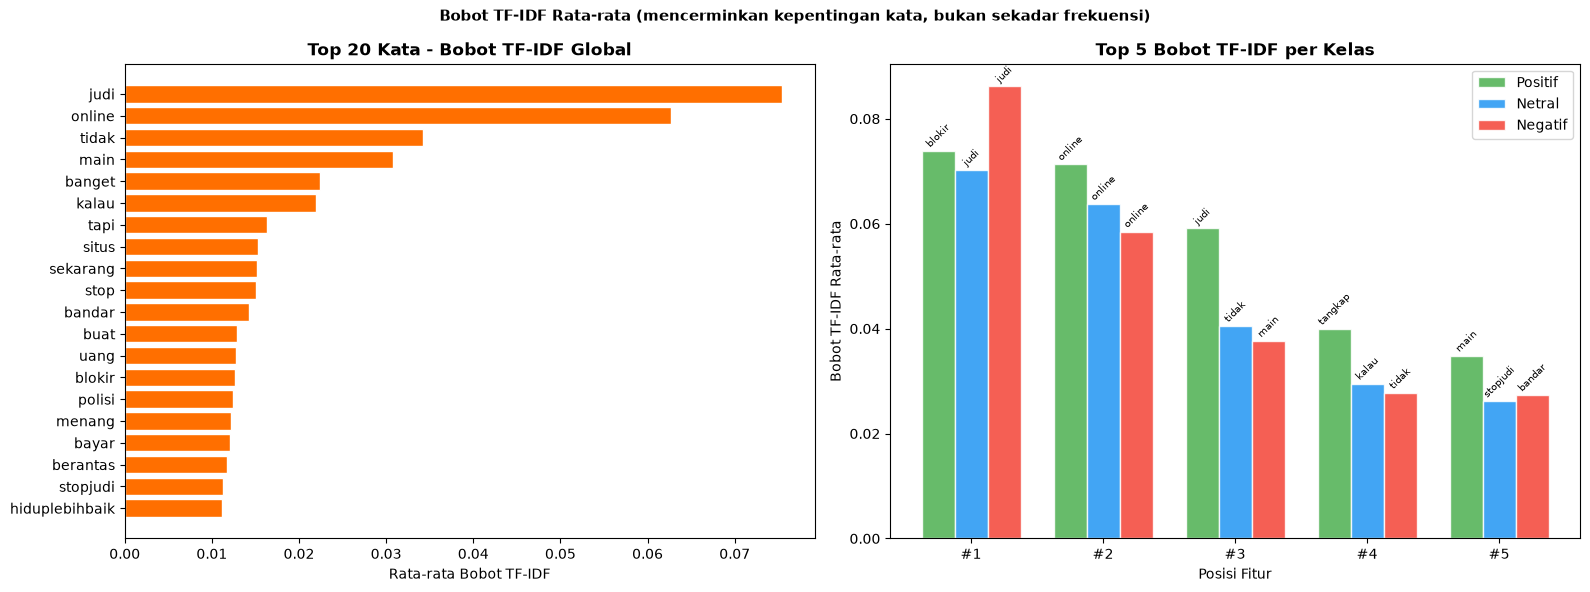

In [10]:
tfidf_viz = TfidfVectorizer(max_features=2000, ngram_range=(1,1), min_df=2)
X_viz      = tfidf_viz.fit_transform(df['text'])
feats_viz  = np.array(tfidf_viz.get_feature_names_out())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bobot TF-IDF Rata-rata (mencerminkan kepentingan kata, bukan sekadar frekuensi)',
             fontsize=11, fontweight='bold')

mean_global = np.array(X_viz.mean(axis=0)).flatten()
top20       = mean_global.argsort()[-20:][::-1]
axes[0].barh(feats_viz[top20][::-1], mean_global[top20][::-1],
             color='#FF6F00', edgecolor='white')
axes[0].set_title('Top 20 Kata - Bobot TF-IDF Global', fontweight='bold')
axes[0].set_xlabel('Rata-rata Bobot TF-IDF')

label_cfg = [('positif','#4CAF50'), ('netral','#2196F3'), ('negatif','#F44336')]
offset = np.arange(5)
width  = 0.25
for i, (lbl, color) in enumerate(label_cfg):
    idx_lbl = df[df['label']==lbl].index
    mean_l  = np.array(X_viz[idx_lbl].mean(axis=0)).flatten()
    top5    = mean_l.argsort()[-5:][::-1]
    axes[1].bar(offset + i*width, mean_l[top5], width=width,
                color=color, alpha=0.85, label=lbl.capitalize(),
                edgecolor='white')
    for j, (pos, val) in enumerate(zip(offset + i*width, mean_l[top5])):
        axes[1].text(pos, val+0.0003, feats_viz[top5[j]],
                     ha='center', va='bottom', fontsize=7, rotation=45)

axes[1].set_title('Top 5 Bobot TF-IDF per Kelas', fontweight='bold')
axes[1].set_xlabel('Posisi Fitur')
axes[1].set_ylabel('Bobot TF-IDF Rata-rata')
axes[1].set_xticks(offset + width); axes[1].set_xticklabels([f'#{i+1}' for i in range(5)])
axes[1].legend()
plt.tight_layout(); plt.show()


## 4. Feature Engineering - TF-IDF Unigram / Bigram / Trigram

In [11]:
le = LabelEncoder()
y  = le.fit_transform(df['label'])
class_names = le.classes_
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    df['text'], y, test_size=0.2, random_state=42, stratify=y
)
test_indices = X_raw_test.index

tfidf_uni = TfidfVectorizer(max_features=1000, ngram_range=(1,1), min_df=2)
tfidf_bi  = TfidfVectorizer(max_features=1000, ngram_range=(2,2), min_df=2)
tfidf_tri = TfidfVectorizer(max_features=1000, ngram_range=(3,3), min_df=2)

X_train_uni = tfidf_uni.fit_transform(X_raw_train)
X_test_uni  = tfidf_uni.transform(X_raw_test)

X_train_bi  = tfidf_bi.fit_transform(X_raw_train)
X_test_bi   = tfidf_bi.transform(X_raw_test)

X_train_tri = tfidf_tri.fit_transform(X_raw_train)
X_test_tri  = tfidf_tri.transform(X_raw_test)

print(f"\nTrain: {X_train_uni.shape[0]} | Test: {X_test_uni.shape[0]}")
print(f"Vocab unigram (dari train): {X_train_uni.shape[1]}")
print(f"Vocab bigram  (dari train): {X_train_bi.shape[1]}")
print(f"Vocab trigram (dari train): {X_train_tri.shape[1]}")


Label encoding: {'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}

Train: 1206 | Test: 302
Vocab unigram (dari train): 1000
Vocab bigram  (dari train): 1000
Vocab trigram (dari train): 1000


## 5. Definisi Model

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.5, class_weight='balanced', random_state=42),
    'Naive Bayes':         MultinomialNB(alpha=1.0),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM':                 SVC(kernel='linear', C=0.5, class_weight='balanced',
                               probability=True, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                                          subsample=0.7, colsample_bytree=0.7,
                                          eval_metric='mlogloss', random_state=42),
}
print(f"Total model: {len(models)}")


Total model: 6


## 5.5 Hyperparameter Tuning XGBoost (GridSearchCV)

Mencari hyperparameter terbaik untuk XGBoost dengan 5-fold cross-validation (F1 weighted) sebelum pelatihan. Model XGBoost pada tahap berikutnya memakai konfigurasi hasil tuning ini.

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_base = XGBClassifier(eval_metric='mlogloss', random_state=42)
grid = GridSearchCV(xgb_base, param_grid, scoring='f1_weighted', cv=5, n_jobs=-1)
grid.fit(X_train_uni, y_train)

print('Best params:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_, 4))

models['XGBoost'] = clone(grid.best_estimator_)

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 1.0}
Best CV F1: 0.8331


## 6. Pelatihan & Evaluasi (Unigram, Bigram, Trigram)

In [14]:
from sklearn.pipeline import Pipeline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(model, X_tr, X_te, vectorizer):
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)
    pipe = Pipeline([('tfidf', clone(vectorizer)), ('clf', clone(model))])
    cv_scores = cross_val_score(pipe, df['text'], y, cv=skf, scoring='f1_weighted', n_jobs=-1)
    return {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted'),
        'CV F1 Mean': cv_scores.mean(),
        'CV F1 Std': cv_scores.std(),
    }

results_uni, results_bi, results_tri = {}, {}, {}

print('Unigram:')
for name, model in models.items():
    results_uni[name] = evaluate(clone(model), X_train_uni, X_test_uni, tfidf_uni)
    r = results_uni[name]
    print(f"  {name}: F1={r['F1-Score']:.4f} AUC={r['ROC-AUC']:.4f} CV={r['CV F1 Mean']:.4f}+/-{r['CV F1 Std']:.4f}")

print('Bigram:')
for name, model in models.items():
    results_bi[name] = evaluate(clone(model), X_train_bi, X_test_bi, tfidf_bi)
    r = results_bi[name]
    print(f"  {name}: F1={r['F1-Score']:.4f} CV={r['CV F1 Mean']:.4f}+/-{r['CV F1 Std']:.4f}")

print('Trigram:')
for name, model in models.items():
    results_tri[name] = evaluate(clone(model), X_train_tri, X_test_tri, tfidf_tri)
    r = results_tri[name]
    print(f"  {name}: F1={r['F1-Score']:.4f} CV={r['CV F1 Mean']:.4f}+/-{r['CV F1 Std']:.4f}")

Unigram:
  Logistic Regression: F1=0.7771 AUC=0.8936 CV=0.8271+/-0.0217
  Naive Bayes: F1=0.6909 AUC=0.8826 CV=0.7689+/-0.0338
  Decision Tree: F1=0.4101 AUC=0.6073 CV=0.4997+/-0.0526
  Random Forest: F1=0.7030 AUC=0.8608 CV=0.7480+/-0.0241
  SVM: F1=0.7790 AUC=0.9025 CV=0.8166+/-0.0228
  XGBoost: F1=0.8157 AUC=0.9262 CV=0.8733+/-0.0180
Bigram:
  Logistic Regression: F1=0.7055 CV=0.7016+/-0.0376
  Naive Bayes: F1=0.6359 CV=0.6956+/-0.0307
  Decision Tree: F1=0.5474 CV=0.5174+/-0.0441
  Random Forest: F1=0.5734 CV=0.6129+/-0.0470
  SVM: F1=0.7027 CV=0.7051+/-0.0398
  XGBoost: F1=0.7235 CV=0.7430+/-0.0294
Trigram:
  Logistic Regression: F1=0.5549 CV=0.5791+/-0.0270
  Naive Bayes: F1=0.5398 CV=0.6051+/-0.0275
  Decision Tree: F1=0.4166 CV=0.3912+/-0.0179
  Random Forest: F1=0.4660 CV=0.4761+/-0.0202
  SVM: F1=0.5477 CV=0.5764+/-0.0322
  XGBoost: F1=0.5600 CV=0.6233+/-0.0251


## 7. Tabel Perbandingan Performa

In [15]:
def make_table(results, title):
    exclude = ('y_pred', 'y_proba')
    tbl = pd.DataFrame({
        k: {m: v for m, v in v.items() if m not in exclude}
        for k, v in results.items()
    }).T.sort_values('F1-Score', ascending=False)
    print(title)
    display(tbl.round(4))
    return tbl

tbl_uni = make_table(results_uni, 'TF-IDF Unigram')
tbl_bi = make_table(results_bi, 'TF-IDF Bigram')
tbl_tri = make_table(results_tri, 'TF-IDF Trigram')

TF-IDF Unigram


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1 Mean,CV F1 Std
XGBoost,0.8179,0.8230,0.8179,0.8157,0.9262,0.8733,0.0180
SVM,0.7815,0.7885,0.7815,0.7790,0.9025,0.8166,0.0228
Logistic Regression,0.7815,0.7927,0.7815,0.7771,0.8936,0.8271,0.0217
Random Forest,0.7086,0.7186,0.7086,0.7030,0.8608,0.7480,0.0241
Naive Bayes,0.7020,0.7249,0.7020,0.6909,0.8826,0.7689,0.0338
Decision Tree,0.5199,0.6542,0.5199,0.4101,0.6073,0.4997,0.0526


TF-IDF Bigram


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1 Mean,CV F1 Std
XGBoost,0.7285,0.7499,0.7285,0.7235,0.8822,0.7430,0.0294
Logistic Regression,0.7086,0.7124,0.7086,0.7055,0.8570,0.7016,0.0376
SVM,0.7053,0.7079,0.7053,0.7027,0.8385,0.7051,0.0398
Naive Bayes,0.6523,0.6717,0.6523,0.6359,0.8270,0.6956,0.0307
Random Forest,0.6093,0.7307,0.6093,0.5734,0.7776,0.6129,0.0470
Decision Tree,0.5497,0.5587,0.5497,0.5474,0.6680,0.5174,0.0441


TF-IDF Trigram


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1 Mean,CV F1 Std
XGBoost,0.5927,0.6758,0.5927,0.5600,0.7780,0.6233,0.0251
Logistic Regression,0.5861,0.6480,0.5861,0.5549,0.7738,0.5791,0.0270
SVM,0.5795,0.6386,0.5795,0.5477,0.7618,0.5764,0.0322
Naive Bayes,0.5795,0.6563,0.5795,0.5398,0.7700,0.6051,0.0275
Random Forest,0.5364,0.7269,0.5364,0.4660,0.6821,0.4761,0.0202
Decision Tree,0.5066,0.7431,0.5066,0.4166,0.5976,0.3912,0.0179


## 8. Visualisasi Perbandingan Semua Model & N-gram

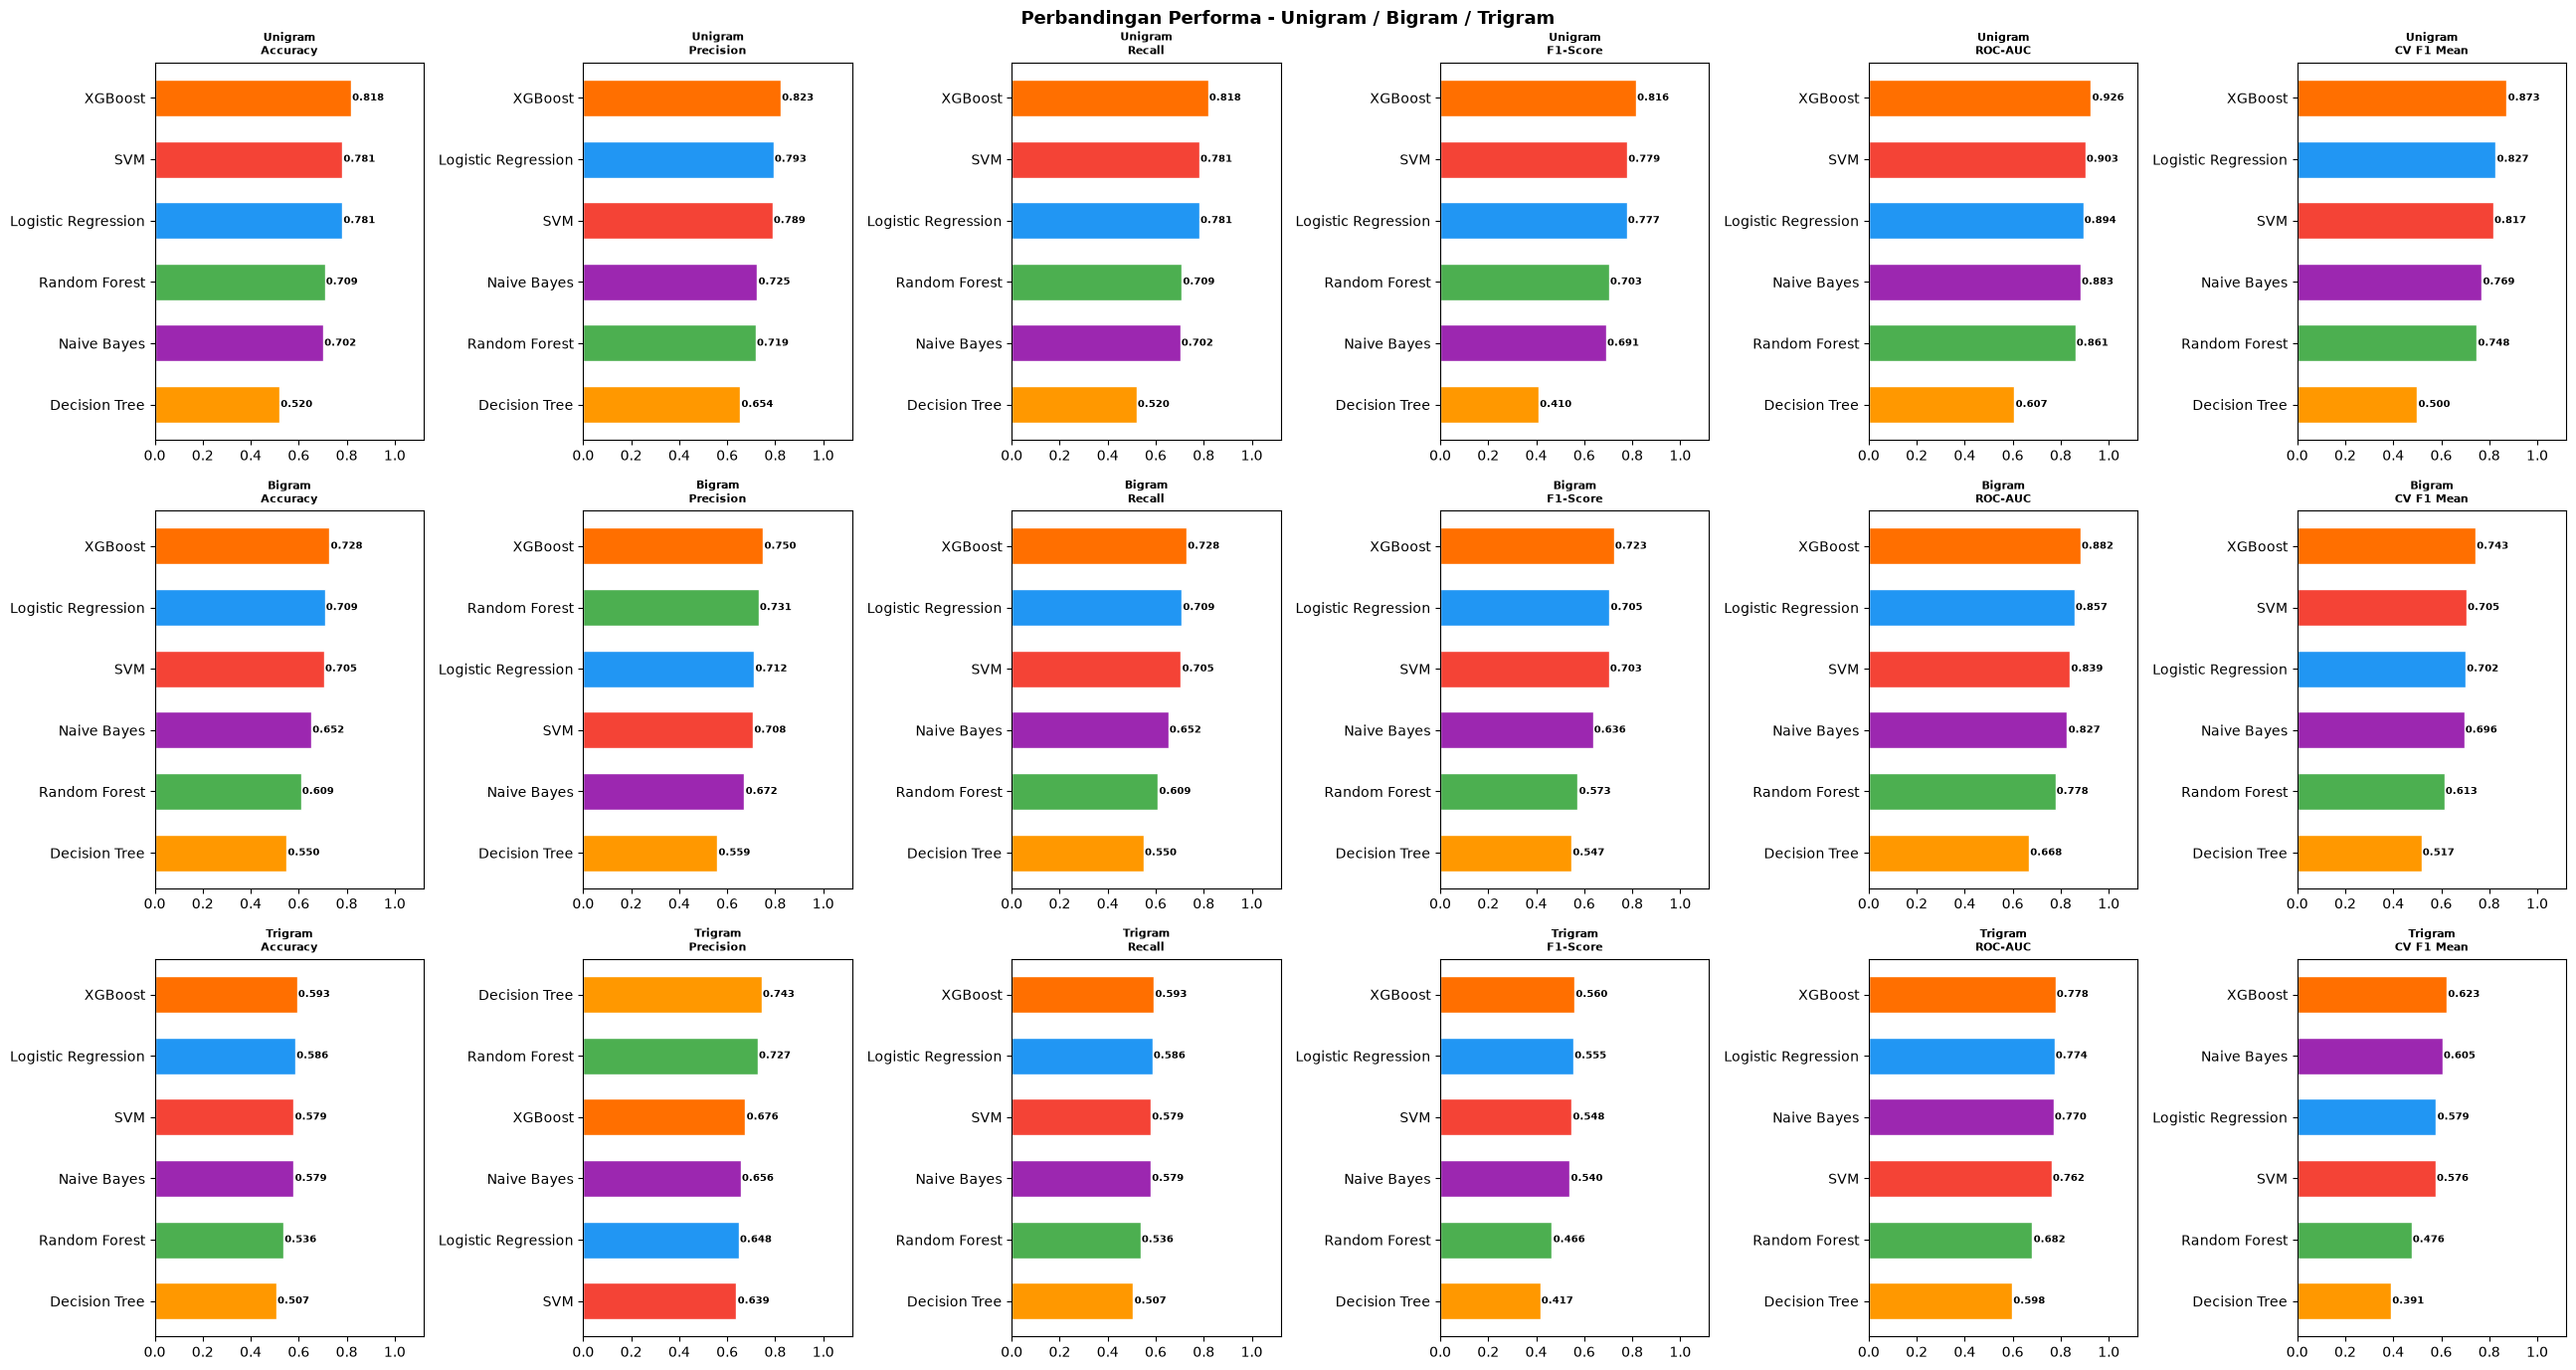

In [16]:
metric_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','CV F1 Mean']
fig, axes = plt.subplots(3, 6, figsize=(26, 14))
fig.suptitle('Perbandingan Performa - Unigram / Bigram / Trigram', fontsize=13, fontweight='bold')

for row_idx, (results, ng_label) in enumerate([
    (results_uni,'Unigram'),(results_bi,'Bigram'),(results_tri,'Trigram')
]):
    tbl = pd.DataFrame({k:{m:v for m,v in v.items() if m not in ('y_pred','y_proba')}
                         for k,v in results.items()}).T
    for col_idx, metric in enumerate(metric_cols):
        ax   = axes[row_idx][col_idx]
        vals = tbl[metric].sort_values()
        bc   = [MODEL_PALETTE[list(tbl.index).index(n)] for n in vals.index]
        bs   = ax.barh(vals.index, vals.values, color=bc, edgecolor='white', height=0.6)
        for bar, val in zip(bs, vals.values):
            ax.text(val+0.005, bar.get_y()+bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=7, fontweight='bold')
        ax.set_xlim(0,1.12); ax.set_title(f'{ng_label}\n{metric}', fontweight='bold', fontsize=8)

plt.tight_layout(); plt.show()


## 9. Confusion Matrix - Semua Model (Unigram)

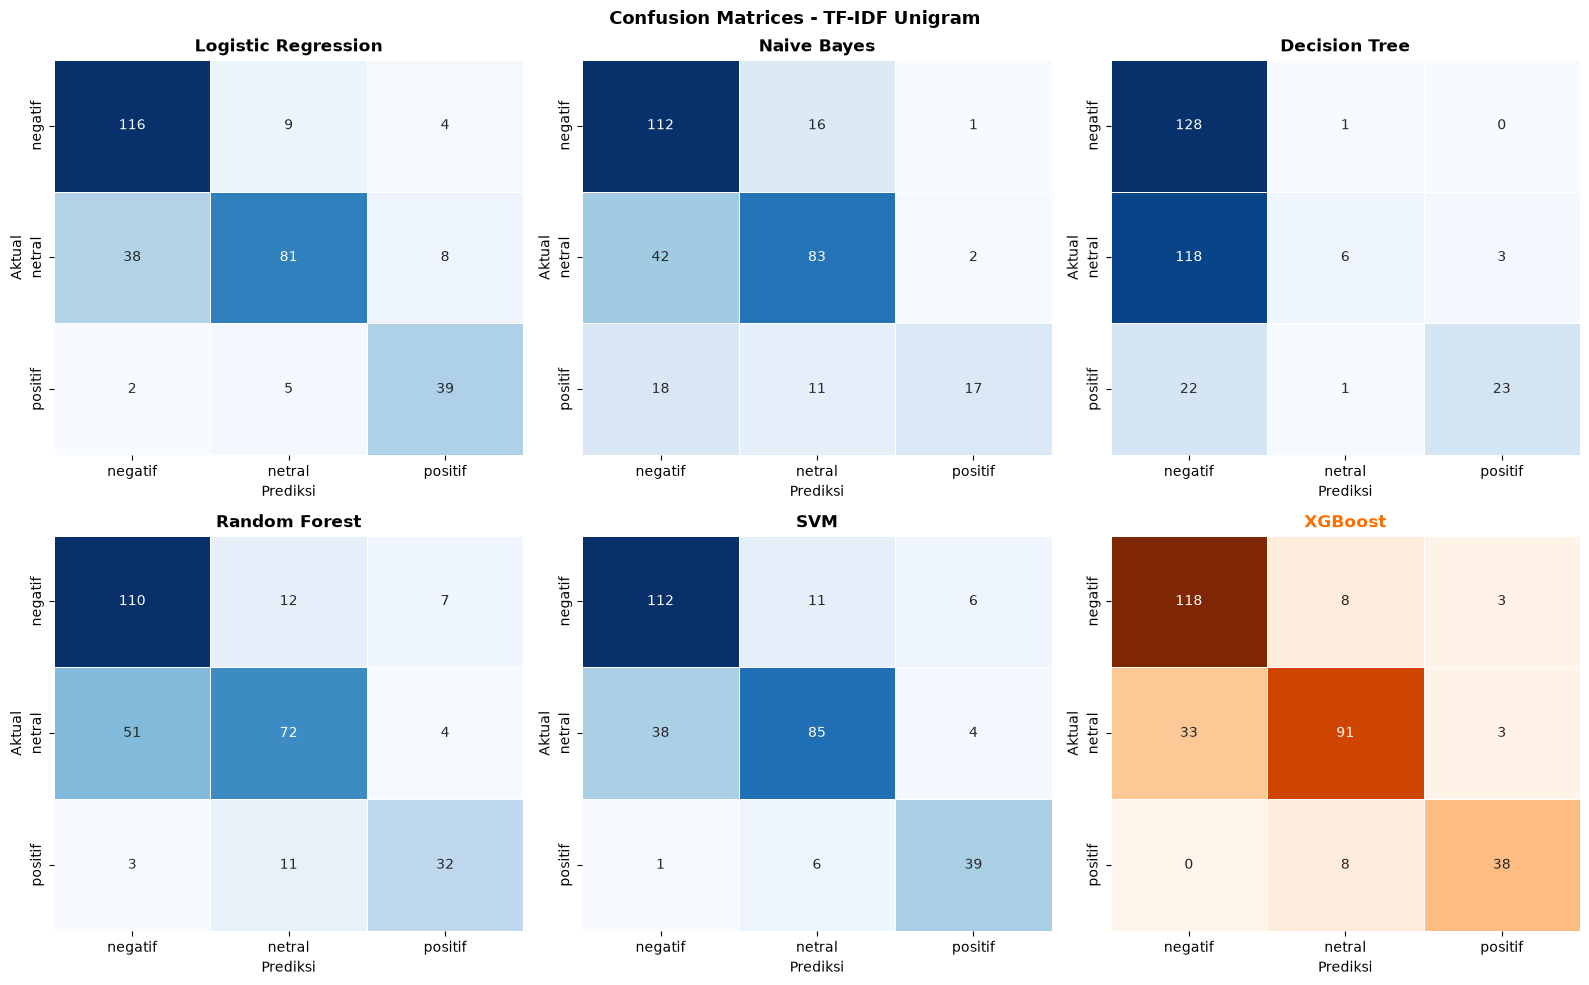

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices - TF-IDF Unigram', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes.flat, results_uni.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    cmap = 'Oranges' if name == 'XGBoost' else 'Blues'
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='white', cbar=False)
    ax.set_title(name, fontweight='bold', color='#FF6F00' if name=='XGBoost' else 'black')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')

plt.tight_layout(); plt.show()


## 9.5 Confusion Matrix - Bigram & Trigram

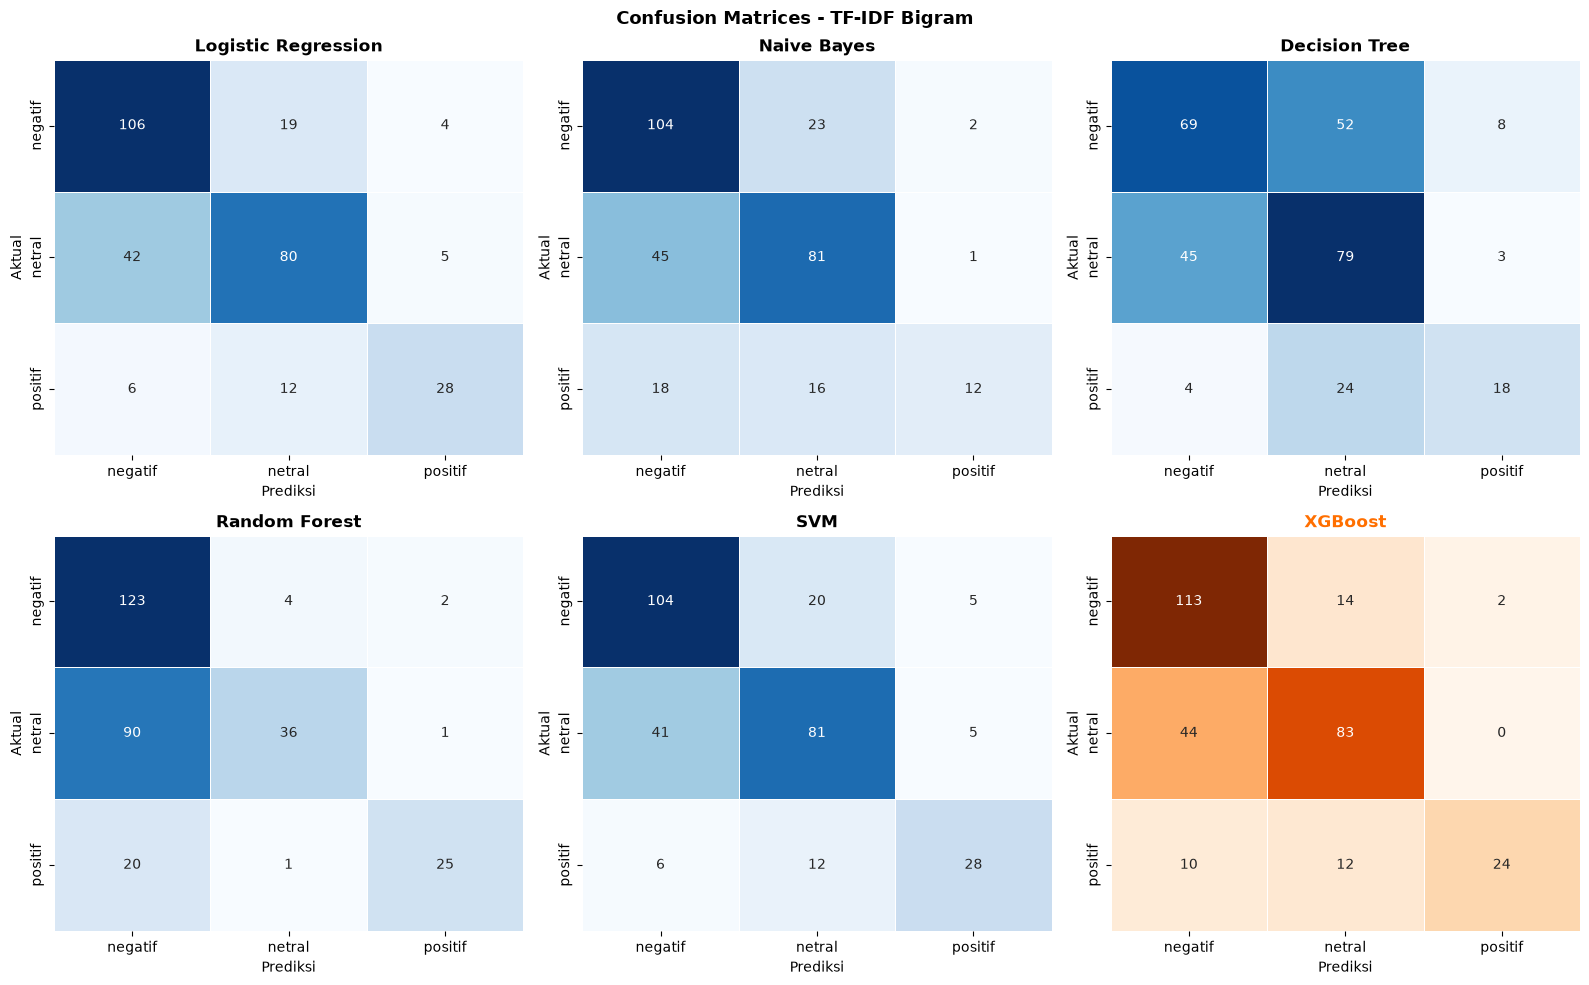

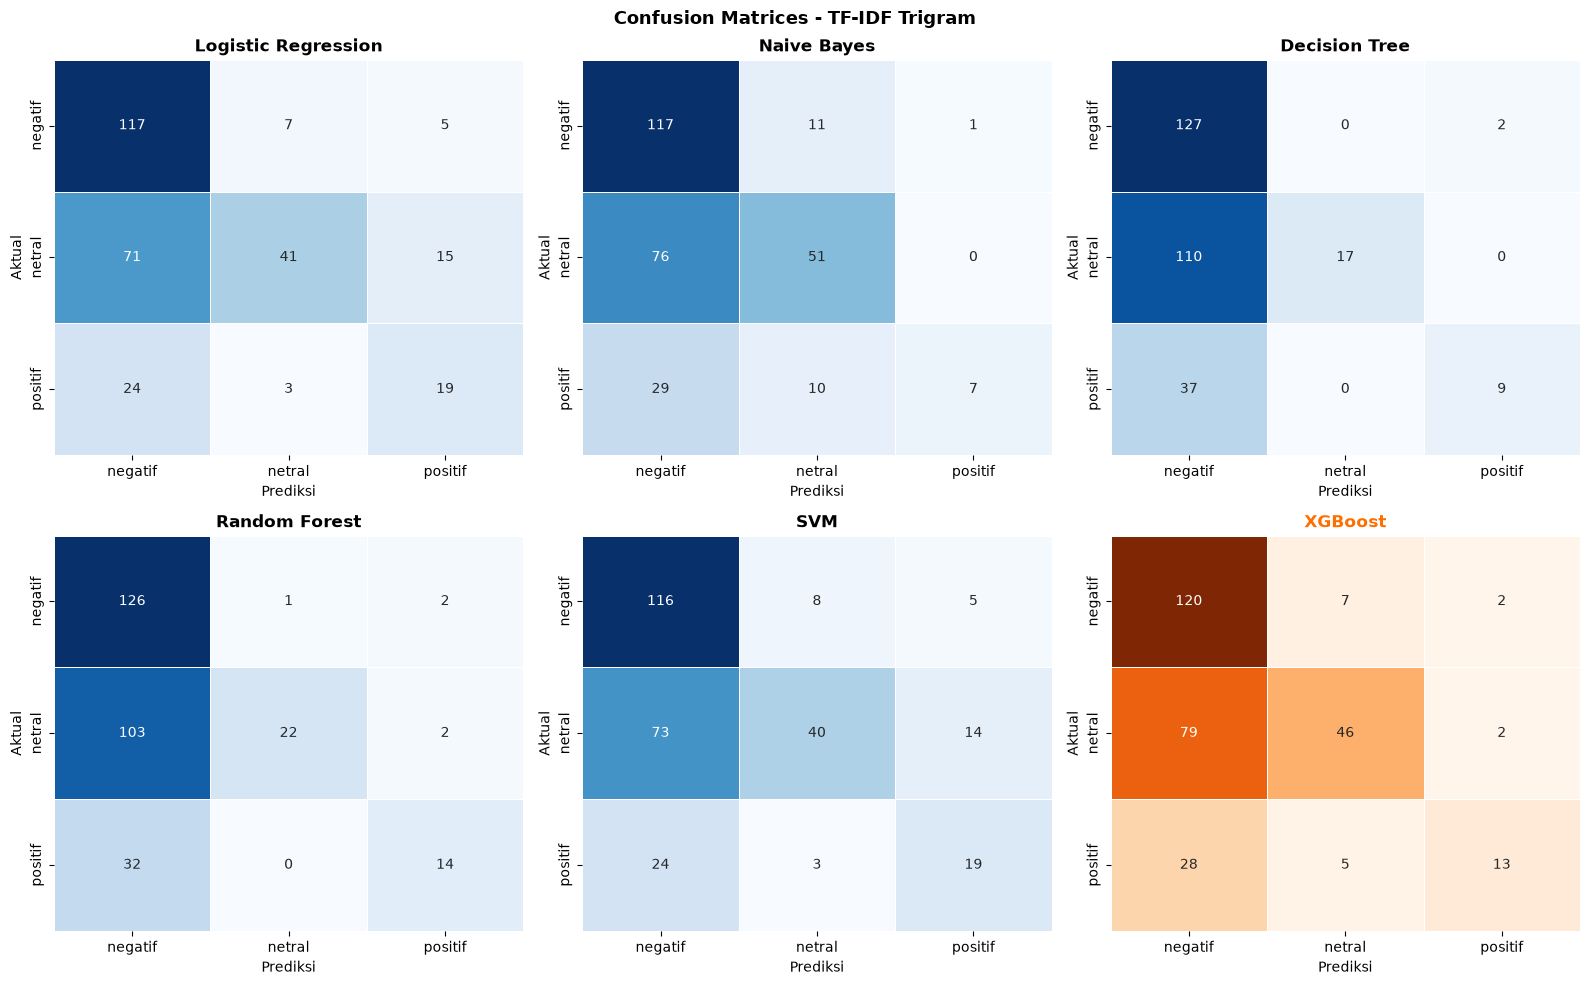

In [18]:
for results, ng_label in [(results_bi, 'Bigram'), (results_tri, 'Trigram')]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f'Confusion Matrices - TF-IDF {ng_label}', fontsize=13, fontweight='bold')
    for ax, (name, res) in zip(axes.flat, results.items()):
        cm   = confusion_matrix(y_test, res['y_pred'])
        cmap = 'Oranges' if name == 'XGBoost' else 'Blues'
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=0.5, linecolor='white', cbar=False)
        ax.set_title(name, fontweight='bold',
                     color='#FF6F00' if name=='XGBoost' else 'black')
        ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
    plt.tight_layout(); plt.show()


## 10. ROC Curves (Macro OvR)

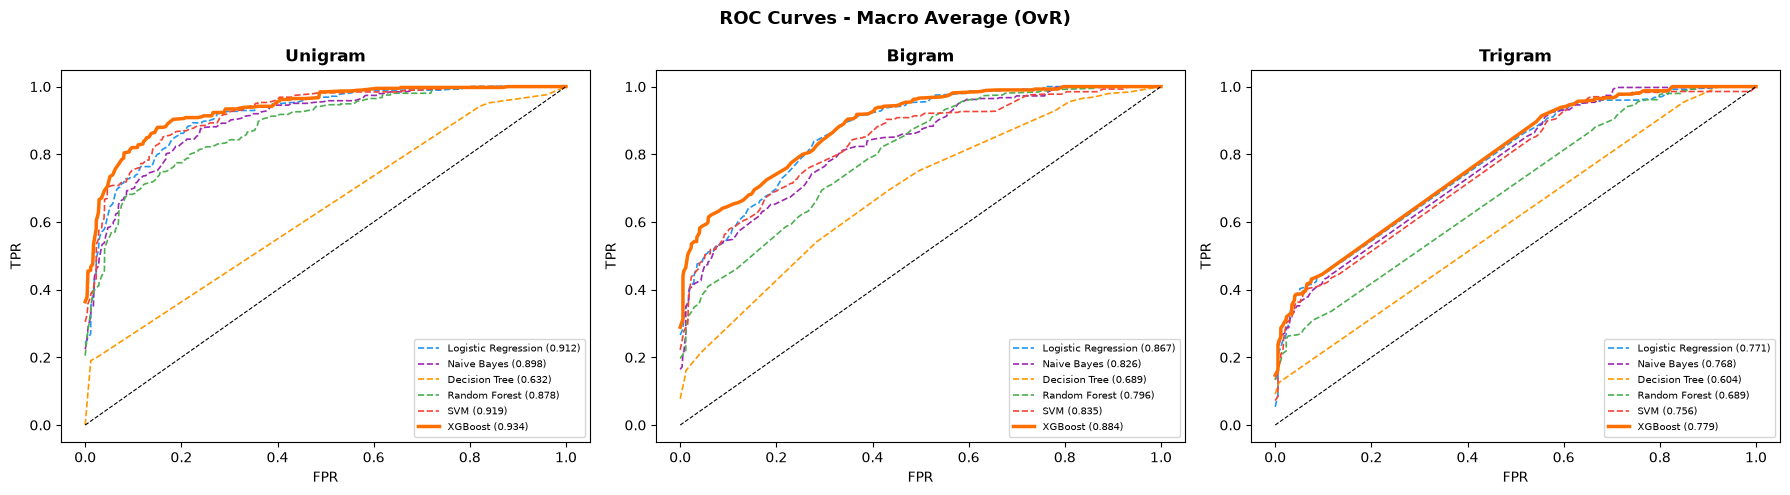

In [19]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves - Macro Average (OvR)', fontsize=13, fontweight='bold')

for ax, (results, label) in zip(axes, [
    (results_uni,'Unigram'),(results_bi,'Bigram'),(results_tri,'Trigram')
]):
    for (name, res), color in zip(results.items(), MODEL_PALETTE):
        fpr_d, tpr_d = {}, {}
        for ci in range(3):
            fpr_d[ci], tpr_d[ci], _ = roc_curve(y_test_bin[:,ci], res['y_proba'][:,ci])
        all_fpr  = np.unique(np.concatenate([fpr_d[i] for i in range(3)]))
        mean_tpr = np.mean([np.interp(all_fpr, fpr_d[i], tpr_d[i]) for i in range(3)], axis=0)
        auc_val  = roc_auc_score(y_test, res['y_proba'], multi_class='ovr', average='macro')
        ax.plot(all_fpr, mean_tpr, lw=2.5 if name=='XGBoost' else 1.2,
                ls='-' if name=='XGBoost' else '--',
                color=color, label=f'{name} ({auc_val:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=0.8); ax.set_title(label, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=7.5, loc='lower right')

plt.tight_layout(); plt.show()


## 11. Feature Importance - XGBoost

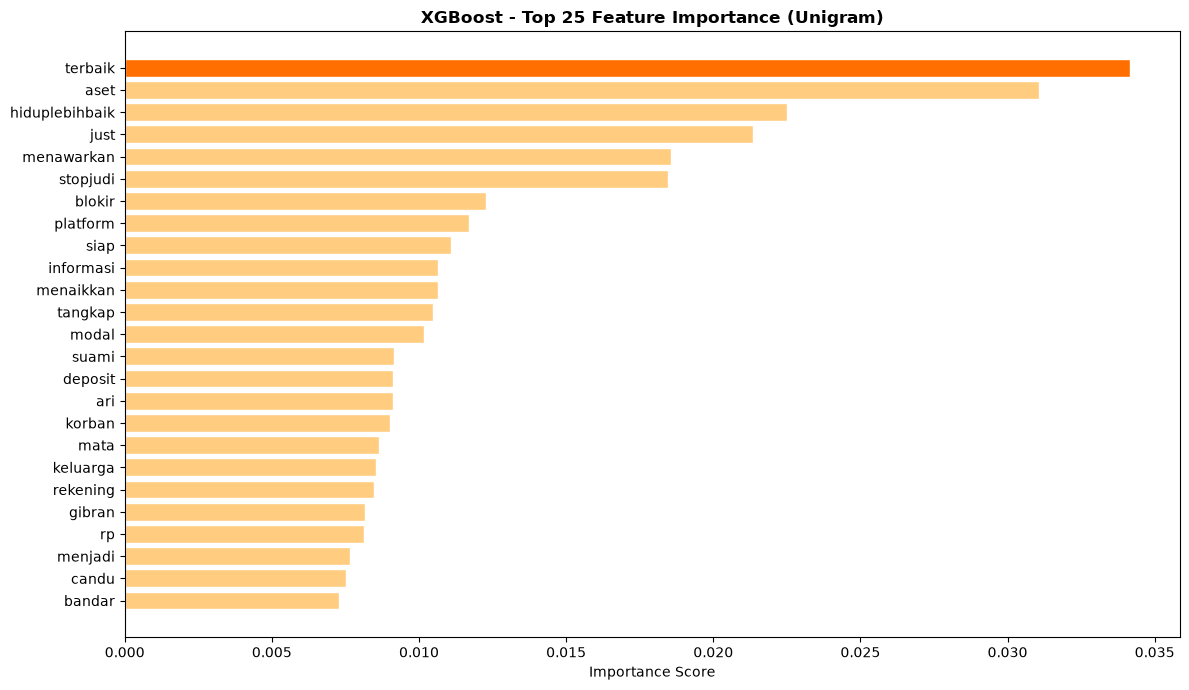

In [20]:
xgb_trained = clone(models['XGBoost'])
xgb_trained.fit(X_train_uni, y_train)

feat_names  = np.array(tfidf_uni.get_feature_names_out())
importances = xgb_trained.feature_importances_
top_idx = importances.argsort()[-25:][::-1]

fig, ax = plt.subplots(figsize=(12, 7))
colors_fi = ['#FF6F00' if i==top_idx[0] else '#FFCC80' for i in top_idx]
ax.barh(feat_names[top_idx][::-1], importances[top_idx][::-1],
        color=colors_fi[::-1], edgecolor='white')
ax.set_title('XGBoost - Top 25 Feature Importance (Unigram)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()


## 11b. Visualisasi Arsitektur XGBoost (Boosting Trees)

Jumlah pohon: 400
Max depth: 5
Jumlah kelas: 3
Butuh graphviz: You must install graphviz to plot tree


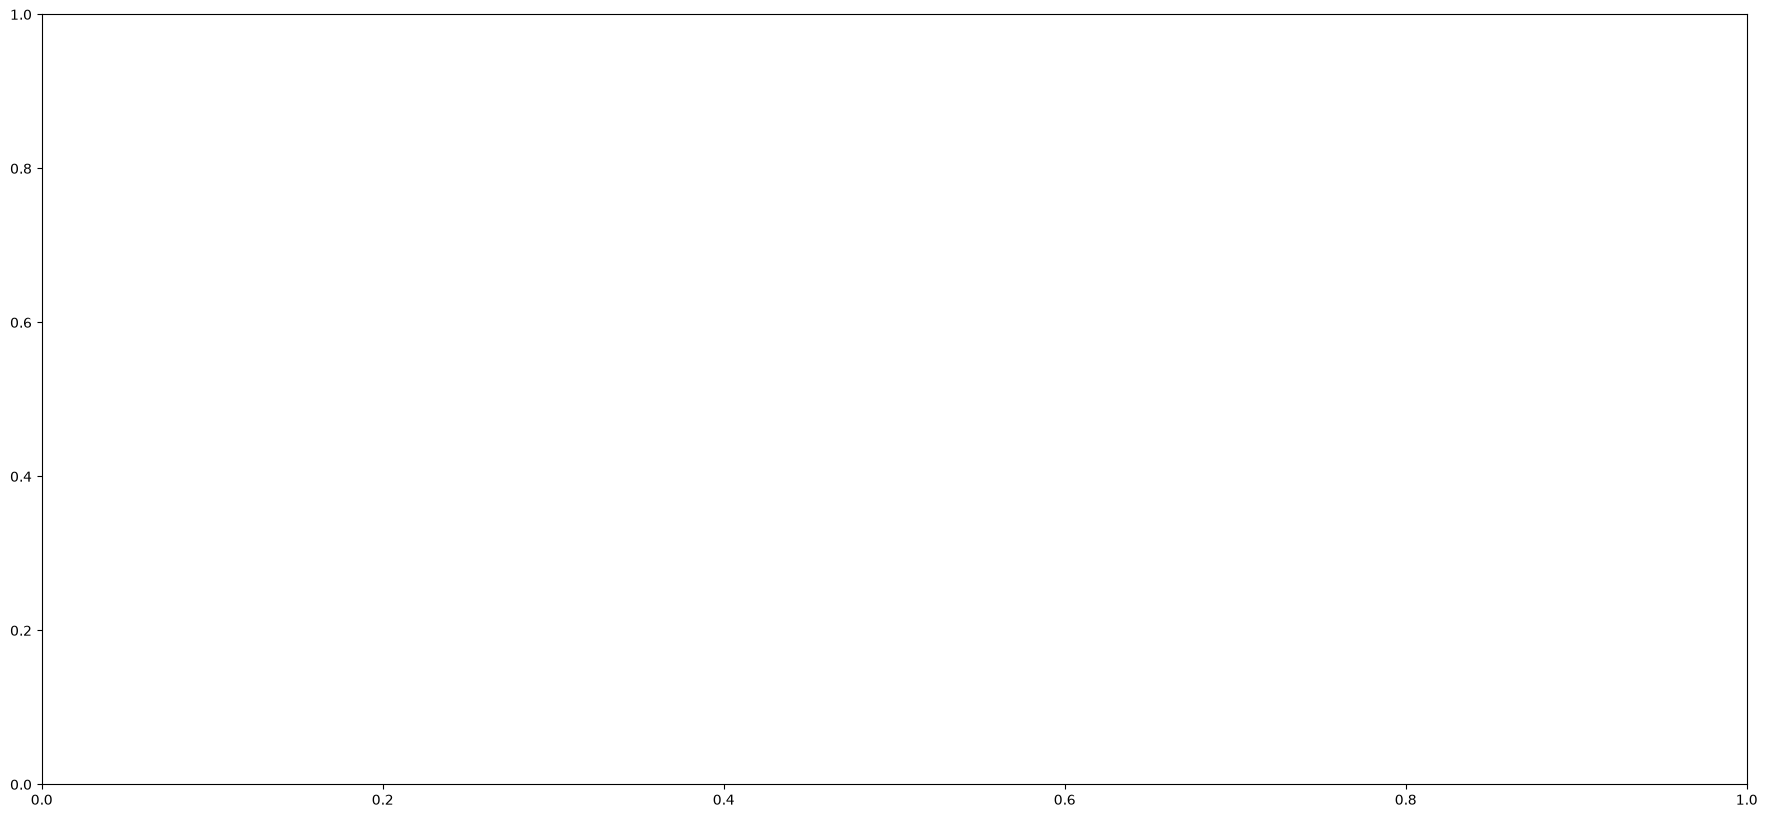

In [21]:
from xgboost import plot_tree

print('Jumlah pohon:', xgb_trained.n_estimators)
print('Max depth:', xgb_trained.max_depth)
print('Jumlah kelas:', len(class_names))

try:
    fig, ax = plt.subplots(figsize=(22, 10))
    plot_tree(xgb_trained, num_trees=0, rankdir='LR', ax=ax)
    ax.set_title('Pohon pertama ensemble XGBoost')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Butuh graphviz:', e)

## 11.5 Analisis Error Model - Contoh Misklasifikasi XGBoost

In [22]:
y_pred_xgb = results_uni['XGBoost']['y_pred']
wrong_mask = (y_test != y_pred_xgb)

raw_test_series = df.loc[test_indices, 'text'].reset_index(drop=True)

error_df = pd.DataFrame({
    'Teks (TEXT_SIAP)': raw_test_series[wrong_mask].values,
    'Label Aktual': le.inverse_transform(y_test[wrong_mask]),
    'Prediksi Model': le.inverse_transform(y_pred_xgb[wrong_mask]),
    'Panjang Token': [len(t.split()) for t in raw_test_series[wrong_mask].values],
})

print('Total salah klasifikasi:', wrong_mask.sum(), 'dari', len(y_test))
print('Error rate:', round(wrong_mask.sum()/len(y_test)*100, 2), '%')

print('Distribusi kesalahan (aktual -> prediksi):')
err_cross = pd.crosstab(
    le.inverse_transform(y_test[wrong_mask]),
    le.inverse_transform(y_pred_xgb[wrong_mask]),
    rownames=['Aktual'], colnames=['Prediksi'])
display(err_cross)

print('Contoh tweet salah klasifikasi:')
display(error_df.head(15))

summary_err = (error_df.groupby(['Label Aktual','Prediksi Model'])['Panjang Token']
               .agg(Jumlah='count', Rata2Token='mean').round(1).reset_index())
display(summary_err)

Total salah klasifikasi: 55 dari 302
Error rate: 18.21 %
Distribusi kesalahan (aktual -> prediksi):


Prediksi,negatif,netral,positif
Aktual,,,
negatif,0,8,3
netral,33,0,3
positif,0,8,0


Contoh tweet salah klasifikasi:


,Teks (TEXT_SIAP),Label Aktual,Prediksi Model,Panjang Token
0,judi online tidak kunjung mati gagalnya berant...,positif,netral,11
1,tidak beda heboh judi online pro judi online s...,netral,negatif,14
2,bu ku berhenti judi online respect tinggi banget,positif,netral,8
3,halah lihat larinya uang mana ingat kasus bank...,netral,negatif,13
4,zaman lakinya judi porno menggila positive pre...,negatif,netral,15
5,pelaku ekonomi bawah minta pak berantas judi o...,netral,positif,28
6,kementerian komunikasi digital komdigi memecat...,positif,netral,25
7,top orang kalau diajak berhubungan susah no of...,netral,negatif,23
8,banget game iki ancen kencanduan e ngalah i judi,netral,negatif,9
9,sebenarnya tebak tebakan hobi judi,netral,negatif,5


,Label Aktual,Prediksi Model,Jumlah,Rata2Token
0,negatif,netral,8,18.1
1,negatif,positif,3,30.3
2,netral,negatif,33,12.4
3,netral,positif,3,23.3
4,positif,netral,8,17.0


## 12. Radar Chart - Perbandingan Menyeluruh

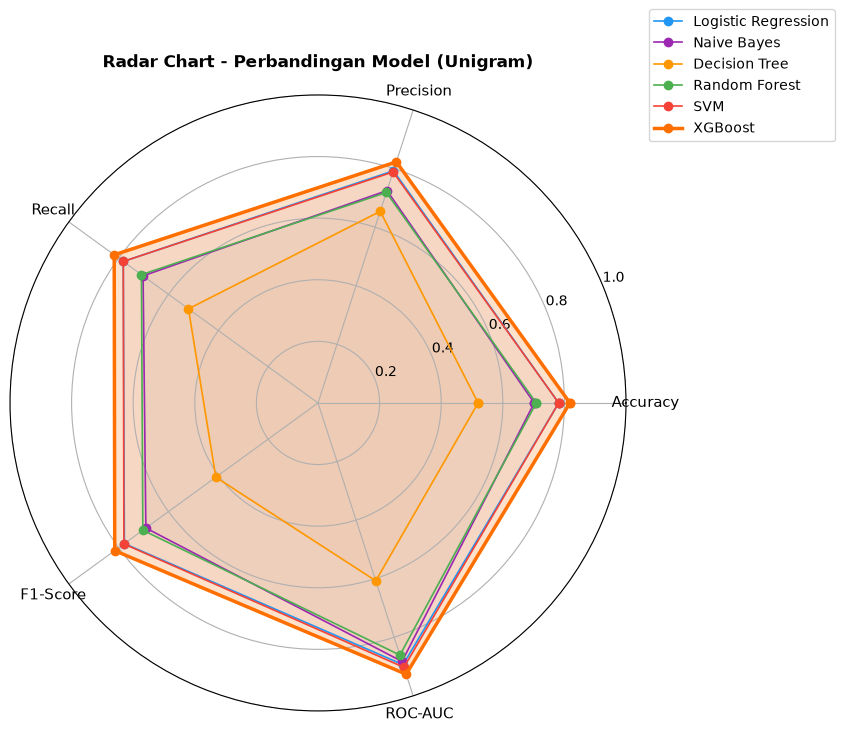

In [23]:
radar_m = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
N = len(radar_m)
angles = [n/float(N)*2*np.pi for n in range(N)] + [0]

fig = plt.figure(figsize=(8,8))
ax  = fig.add_subplot(111, polar=True)

tbl_uni_r = pd.DataFrame({k:{m:v for m,v in v.items() if m not in ('y_pred','y_proba')}
                            for k,v in results_uni.items()}).T

for (mname, row), mc in zip(tbl_uni_r[radar_m].iterrows(), MODEL_PALETTE):
    vals_r = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals_r, 'o-', lw=2.5 if mname=='XGBoost' else 1.2, color=mc, label=mname)
    ax.fill(angles, vals_r, alpha=0.2 if mname=='XGBoost' else 0.04, color=mc)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_m, fontsize=11)
ax.set_ylim(0,1)
ax.set_title('Radar Chart - Perbandingan Model (Unigram)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.15))
plt.show()


## 13. Classification Report - XGBoost

Classification Report - XGBoost (Unigram)
              precision    recall  f1-score   support

     negatif     0.7815    0.9147    0.8429       129
      netral     0.8505    0.7165    0.7778       127
     positif     0.8636    0.8261    0.8444        46

    accuracy                         0.8179       302
   macro avg     0.8319    0.8191    0.8217       302
weighted avg     0.8230    0.8179    0.8157       302



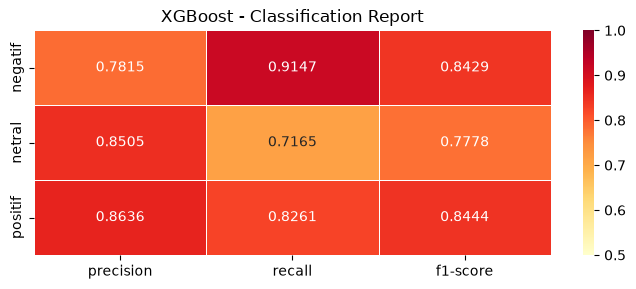

In [24]:
print('Classification Report - XGBoost (Unigram)')
print(classification_report(y_test, results_uni['XGBoost']['y_pred'],
                            target_names=class_names, digits=4))

rep = classification_report(y_test, results_uni['XGBoost']['y_pred'],
                            target_names=class_names, output_dict=True)
rep_df = pd.DataFrame(rep).T.loc[class_names, ['precision','recall','f1-score']].astype(float)

fig, ax = plt.subplots(figsize=(7,3))
sns.heatmap(rep_df, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white', vmin=0.5, vmax=1.0)
ax.set_title('XGBoost - Classification Report')
plt.tight_layout(); plt.show()

## 13.5 Pengujian Statistik - Cross-Validation Detail per Model

Cross-validation 5-fold (unigram):
Model                    CV F1 Mean    CV F1 Std    Test F1      Gap
Logistic Regression          0.8271       0.0217     0.7771  -0.0500
Naive Bayes                  0.7689       0.0338     0.6909  -0.0780
Decision Tree                0.4997       0.0526     0.4101  -0.0896
Random Forest                0.7480       0.0241     0.7030  -0.0449
SVM                          0.8166       0.0228     0.7790  -0.0376
XGBoost                      0.8733       0.0180     0.8157  -0.0575


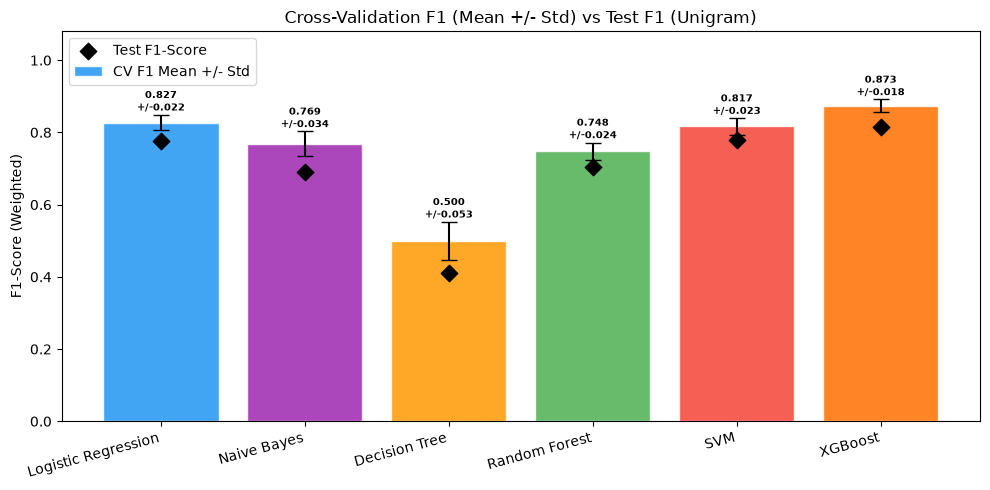

In [25]:
print('Cross-validation 5-fold (unigram):')
print(f"{'Model':<22} {'CV F1 Mean':>12} {'CV F1 Std':>12} {'Test F1':>10} {'Gap':>8}")
for name, res in results_uni.items():
    gap = res['F1-Score'] - res['CV F1 Mean']
    print(f"{name:<22} {res['CV F1 Mean']:>12.4f} {res['CV F1 Std']:>12.4f}"
          f" {res['F1-Score']:>10.4f} {gap:>+8.4f}")

model_names = list(results_uni.keys())
means = [results_uni[n]['CV F1 Mean'] for n in model_names]
stds = [results_uni[n]['CV F1 Std'] for n in model_names]
test_f1 = [results_uni[n]['F1-Score'] for n in model_names]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(model_names))
ax.bar(x, means, yerr=stds, color=MODEL_PALETTE, edgecolor='white',
       capsize=6, alpha=0.85, label='CV F1 Mean +/- Std')
ax.scatter(x, test_f1, color='black', zorder=5, s=70, marker='D', label='Test F1-Score')
for i, (mean, std, tf) in enumerate(zip(means, stds, test_f1)):
    ax.text(i, mean + std + 0.012, f'{mean:.3f}\n+/-{std:.3f}',
            ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.08)
ax.set_ylabel('F1-Score (Weighted)')
ax.set_title('Cross-Validation F1 (Mean +/- Std) vs Test F1 (Unigram)')
ax.legend(); plt.tight_layout(); plt.show()

## 13.6 Penanganan Imbalanced Data (SMOTE)

Distribusi kelas tidak seimbang. SMOTE diterapkan pada data latih untuk menyeimbangkan jumlah sampel tiap kelas, lalu tiap model dilatih ulang dan F1-score-nya dibandingkan dengan kondisi tanpa SMOTE. SMOTE hanya diterapkan pada data latih agar tidak bocor ke data uji.

In [26]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

label_map = dict(enumerate(class_names))
print('Sebelum SMOTE:')
print(pd.Series(y_train).map(label_map).value_counts())

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_uni_sm, y_train_sm = smote.fit_resample(X_train_uni, y_train)

print('Sesudah SMOTE:')
print(pd.Series(y_train_sm).map(label_map).value_counts())

rows = []
for name, model in models.items():
    base = clone(model)
    base.fit(X_train_uni, y_train)
    f1_base = f1_score(y_test, base.predict(X_test_uni), average='weighted', zero_division=0)

    smt = clone(model)
    smt.fit(X_train_uni_sm, y_train_sm)
    f1_smote = f1_score(y_test, smt.predict(X_test_uni), average='weighted', zero_division=0)

    rows.append({'Model': name, 'F1 Tanpa SMOTE': f1_base,
                 'F1 Dengan SMOTE': f1_smote, 'Selisih': f1_smote - f1_base})

tbl_smote = pd.DataFrame(rows).sort_values('F1 Dengan SMOTE', ascending=False).reset_index(drop=True)
tbl_smote.round(4)


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Sebelum SMOTE:
negatif    514
netral     510
positif    182
Name: count, dtype: int64
Sesudah SMOTE:
netral     514
negatif    514
positif    514
Name: count, dtype: int64


,Model,F1 Tanpa SMOTE,F1 Dengan SMOTE,Selisih
0,XGBoost,0.8157,0.8294,0.0137
1,SVM,0.7790,0.7926,0.0136
2,Logistic Regression,0.7771,0.7834,0.0063
3,Random Forest,0.7030,0.7171,0.0140
4,Naive Bayes,0.6909,0.7099,0.0190
5,Decision Tree,0.4101,0.4709,0.0608


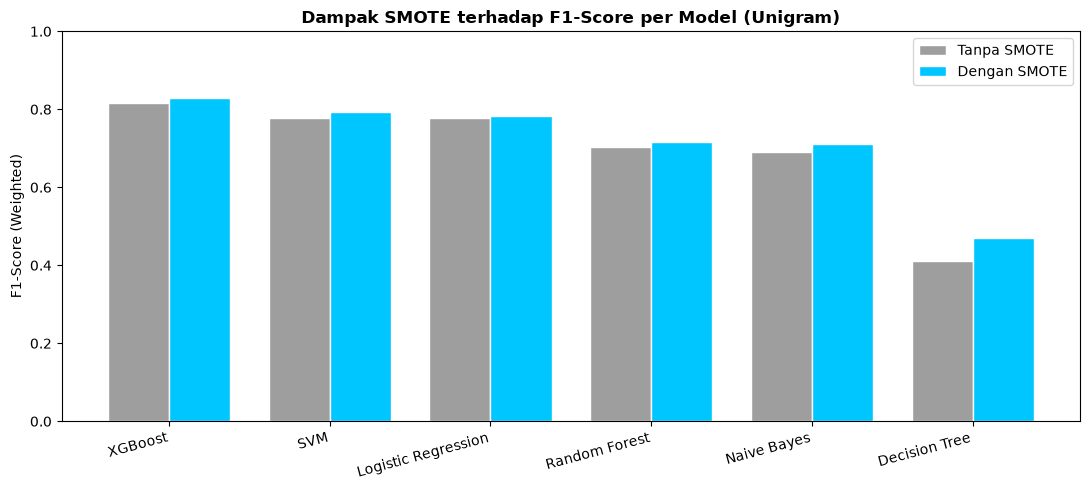

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(tbl_smote))
w = 0.38
ax.bar(x - w/2, tbl_smote['F1 Tanpa SMOTE'], width=w, label='Tanpa SMOTE', color='#9E9E9E', edgecolor='white')
ax.bar(x + w/2, tbl_smote['F1 Dengan SMOTE'], width=w, label='Dengan SMOTE', color='#00C6FF', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(tbl_smote['Model'], rotation=15, ha='right')
ax.set_ylabel('F1-Score (Weighted)'); ax.set_ylim(0, 1.0)
ax.set_title('Dampak SMOTE terhadap F1-Score per Model (Unigram)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

## 14. Kesimpulan

Catatan hasil:
- Label dibentuk dari majority vote 3 anotator, sehingga sebagian sampel ambigu dan sulit dipisahkan.
- Teks media sosial mengandung sarkasme dan bahasa campuran yang tidak tertangkap oleh TF-IDF.
- Skor cross-validation dan skor test berdekatan, menandakan model tidak overfit.

Perbandingan n-gram:
- Unigram: vocab terbesar dan paling stabil.
- Bigram: menangkap frasa seperti "judi online", lebih sparse.
- Trigram: paling sparse, performa menurun pada data kecil.

Model:
- Logistic Regression dan SVM sedikit unggul pada unigram.
- XGBoost konsisten pada cross-validation.

Penanganan imbalanced data:
- Model linear dan tree-based memakai class weight balanced.
- SMOTE diuji sebagai pembanding (bagian 13.6).

Menyimpan pipeline:

```python
import joblib
pipeline = {'tfidf': tfidf_uni, 'model': xgb_trained, 'label_encoder': le}
joblib.dump(pipeline, 'judol_pipeline.pkl')
```